          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

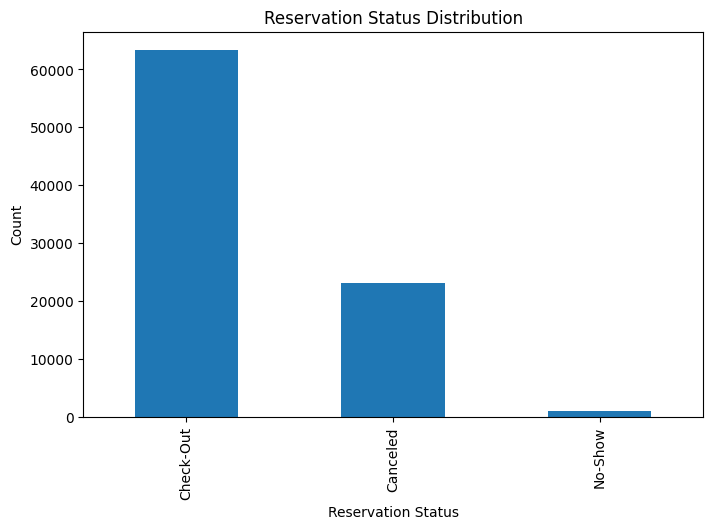

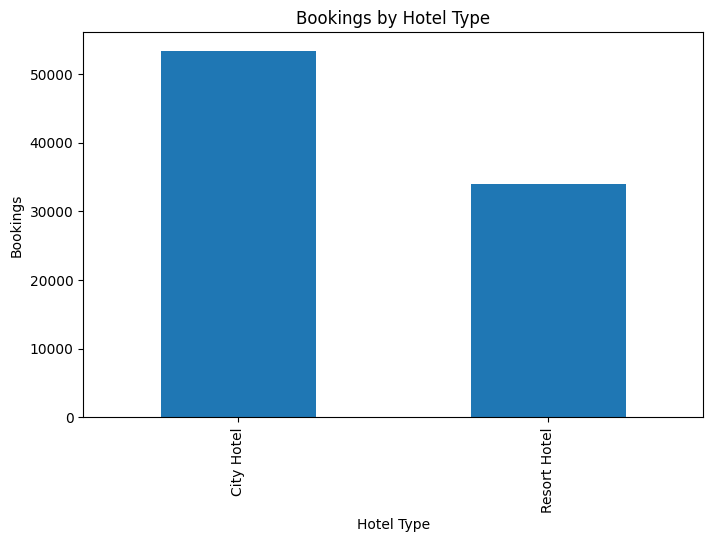

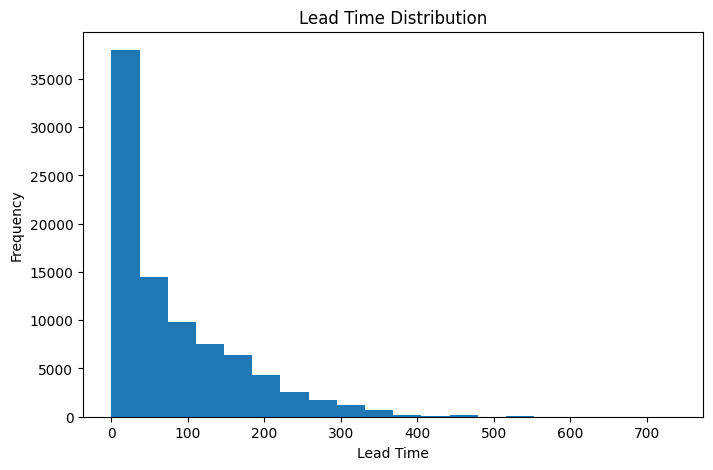

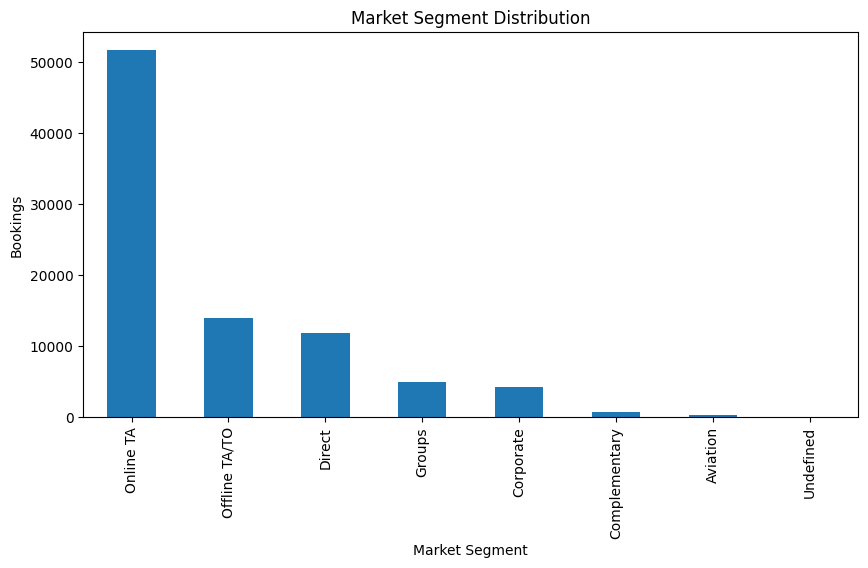

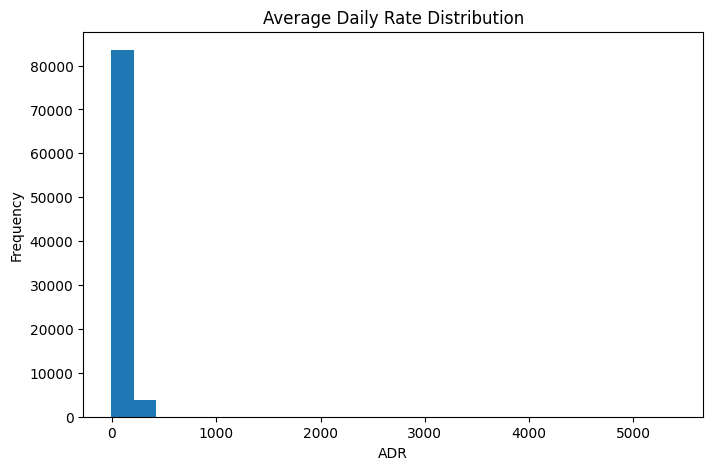

Cancellation Rate: 27.49%
Average Stay Duration: 3.63 nights
Most Common Market Segment: Online TA
Country with Highest Bookings: PRT
Most Preferred Hotel Type: City Hotel

----- AUTOMATED REPORT SUMMARY -----
Original Dataset Processed Successfully
Missing Values Handled
Duplicate Records Removed
Data Standardization Completed
Visual Reports Generated
Cleaned Dataset Exported Successfully


In [ ]:
#Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Load Dataset
df = pd.read_csv("/content/drive/MyDrive/Datasets/hotel_bookings.csv")

#Display Dataset
print(df.head())

#Dataset Information
print("Dataset Shape:", df.shape)
print(df.info())

#Statistical Summary
print(df.describe())

#Check Missing Values
print(df.isnull().sum())

#Handle Missing Values

#Fill Numerical Columns with Median
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

#Fill Categorical Columns with Mode
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

#Verify Missing Values
print(df.isnull().sum())

#Check Duplicate Records
print("Duplicate Rows:", df.duplicated().sum())

#Remove Duplicate Records
df = df.drop_duplicates()

#Dataset Shape After Removing Duplicates
print("Dataset Shape After Removing Duplicates:", df.shape)

#Standardize Column Names
df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]

print(df.columns)

#Feature Engineering

#Create Total Stay Nights Column
df['total_stay_nights'] = (
    df['stays_in_weekend_nights'] +
    df['stays_in_week_nights']
)

print(df[['stays_in_weekend_nights',
          'stays_in_week_nights',
          'total_stay_nights']].head())

#Save Cleaned Dataset
df.to_csv("cleaned_hotel_bookings.csv", index=False)

print("Cleaned Dataset Saved Successfully")

#Reservation Status Distribution
plt.figure(figsize=(8,5))

df['reservation_status'].value_counts().plot(kind='bar')

plt.title("Reservation Status Distribution")
plt.xlabel("Reservation Status")
plt.ylabel("Count")

plt.show()

#Hotel Booking Distribution
plt.figure(figsize=(8,5))

df['hotel'].value_counts().plot(kind='bar')

plt.title("Bookings by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Bookings")

plt.show()

#Lead Time Distribution
plt.figure(figsize=(8,5))

plt.hist(df['lead_time'], bins=20)

plt.title("Lead Time Distribution")
plt.xlabel("Lead Time")
plt.ylabel("Frequency")

plt.show()

#Market Segment Distribution
plt.figure(figsize=(10,5))

df['market_segment'].value_counts().plot(kind='bar')

plt.title("Market Segment Distribution")
plt.xlabel("Market Segment")
plt.ylabel("Bookings")

plt.show()

#Average Daily Rate Distribution
plt.figure(figsize=(8,5))

plt.hist(df['adr'], bins=25)

plt.title("Average Daily Rate Distribution")
plt.xlabel("ADR")
plt.ylabel("Frequency")

plt.show()

#Cancellation Rate
cancellation_rate = df['is_canceled'].mean() * 100

print("Cancellation Rate: {:.2f}%".format(cancellation_rate))

#Average Stay Duration
average_stay = df['total_stay_nights'].mean()

print("Average Stay Duration:", round(average_stay, 2), "nights")

#Most Common Market Segment
most_common_segment = df['market_segment'].mode()[0]

print("Most Common Market Segment:", most_common_segment)

#Country with Highest Bookings
highest_booking_country = df['country'].mode()[0]

print("Country with Highest Bookings:", highest_booking_country)

#Most Preferred Hotel Type
preferred_hotel = df['hotel'].mode()[0]

print("Most Preferred Hotel Type:", preferred_hotel)

#Automated Reporting Summary
print("\n----- AUTOMATED REPORT SUMMARY -----")

print("Original Dataset Processed Successfully")
print("Missing Values Handled")
print("Duplicate Records Removed")
print("Data Standardization Completed")
print("Visual Reports Generated")
print("Cleaned Dataset Exported Successfully")